# Classificação: sistema de apoio à decisão p/ aprovação de crédito
Romain Sebire - 125 009 460

## Importação das bibliotecas e dos dados

Nesta célula, estamos importando as bibliotecas essenciais para análise de dados, visualização, pré-processamento, treinamento e avaliação de modelos de machine learning.

In [49]:
# --- Importações iniciais ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from collections import Counter
import optuna

In [35]:
# --- Carregamento dos dados ---
train_df = pd.read_csv('data/conjunto_de_treinamento.csv')
test_df = pd.read_csv('data/conjunto_de_teste.csv')
sample_submission = pd.read_csv('data/exemplo_arquivo_respostas.csv')

print("Dimensões do conjunto de treinamento:", train_df.shape)
print("Dimensões do conjunto de teste:", test_df.shape)

Dimensões do conjunto de treinamento: (4683, 21)
Dimensões do conjunto de teste: (2000, 20)


Os dados foram importados corretamente: há 4.683 linhas no conjunto de treinamento e 2.000 linhas no conjunto de teste.  
Há 21 colunas de dados no conjunto de treinamento e apenas 20 no conjunto de teste, pois a coluna de resposta está ausente.

## Análise Exploratória de Dados

### Exibição das features e contagem dos valores ausentes

In [19]:
# Para visualizar todas as colunas
pd.set_option('display.max_columns', None)

# Exibição das primeiras linhas
train_df.head()

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,preco
0,2000,Casa,Imbiribeira,Imobiliaria,3,3,5,223,167,piscina e copa,0,0,1,0,0,0,0,0,0,0,1000000.0
1,2001,Apartamento,Casa Amarela,Imobiliaria,4,4,2,157,0,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0,680000.0
2,2002,Apartamento,Encruzilhada,Imobiliaria,3,1,0,53,0,nenhum,0,0,0,0,0,0,0,0,0,0,450000.0
3,2003,Apartamento,Boa Viagem,Imobiliaria,4,3,2,149,0,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0,1080000.0
4,2004,Apartamento,Rosarinho,Imobiliaria,2,1,1,54,0,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0,350000.0


In [20]:
# Exibição da lista de features e seus tipos
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4683 entries, 0 to 4682
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              4683 non-null   int64  
 1   tipo            4683 non-null   object 
 2   bairro          4683 non-null   object 
 3   tipo_vendedor   4683 non-null   object 
 4   quartos         4683 non-null   int64  
 5   suites          4683 non-null   int64  
 6   vagas           4683 non-null   int64  
 7   area_util       4683 non-null   int64  
 8   area_extra      4683 non-null   int64  
 9   diferenciais    4683 non-null   object 
 10  churrasqueira   4683 non-null   int64  
 11  estacionamento  4683 non-null   int64  
 12  piscina         4683 non-null   int64  
 13  playground      4683 non-null   int64  
 14  quadra          4683 non-null   int64  
 15  s_festas        4683 non-null   int64  
 16  s_jogos         4683 non-null   int64  
 17  s_ginastica     4683 non-null   i

In [21]:
# Exibição das features com valores ausentes (train_df)
missing_train = train_df.isnull().sum()
missing_train[missing_train > 0].sort_values(ascending=False)

# Exibição das features com valores ausentes (test_df)
missing_test = test_df.isnull().sum()
missing_test[missing_test > 0].sort_values(ascending=False)

Series([], dtype: int64)

Nenhum valor ausente, nem nos dados de treino, nem nos dados de teste.

### Plotagem das distribuições das features categóricas

Vamos analisar a distribuição de cada feature. Isso permite explorar visualmente a repartição dos dados em cada feature, sendo útil para entender sua estrutura, detectar desequilíbrios ou anomalias e orientar as escolhas no tratamento dos dados.


Distribuição de 'tipo' (valores ausentes: 0)


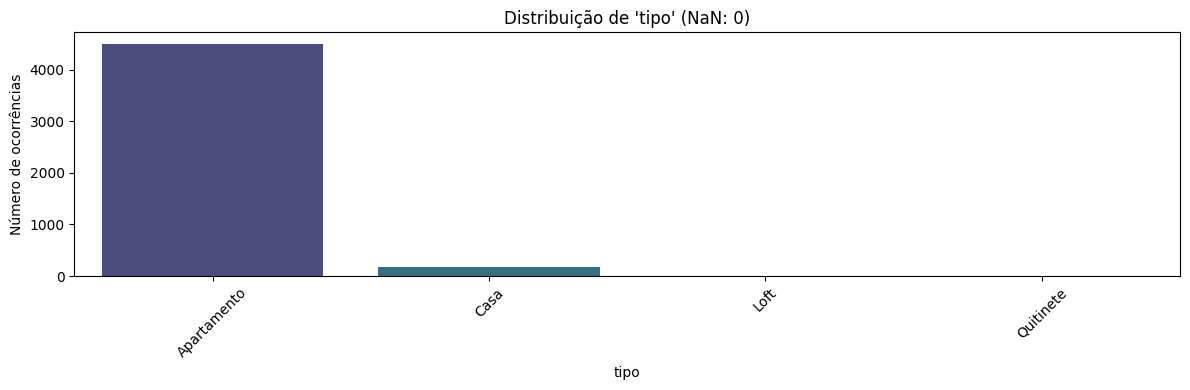


Distribuição de 'bairro' (valores ausentes: 0)


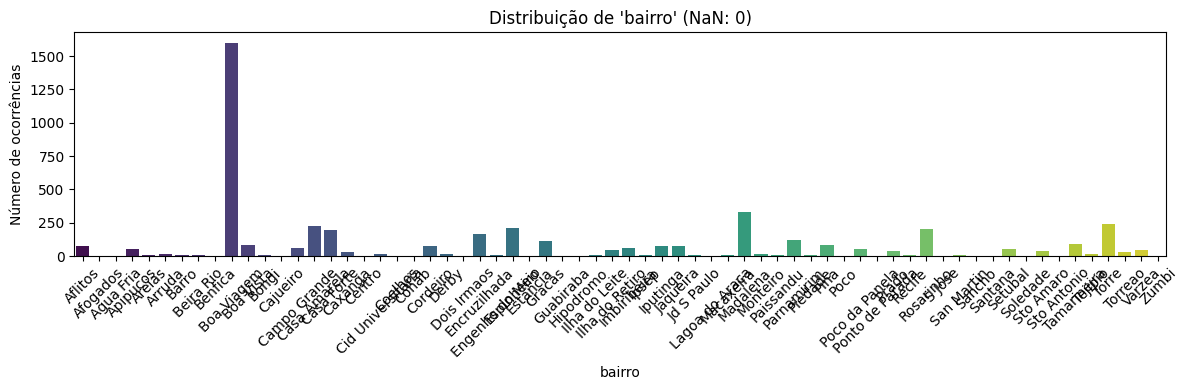


Distribuição de 'tipo_vendedor' (valores ausentes: 0)


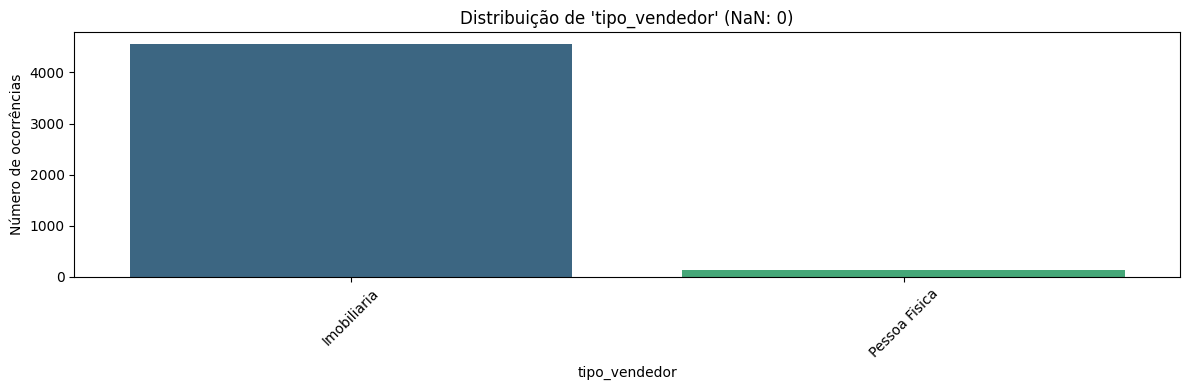


Distribuição de 'quartos' (valores ausentes: 0)


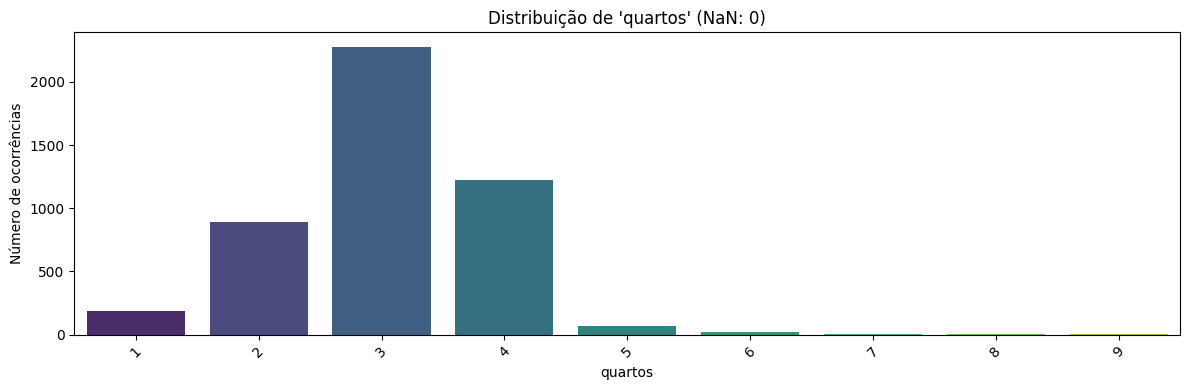


Distribuição de 'suites' (valores ausentes: 0)


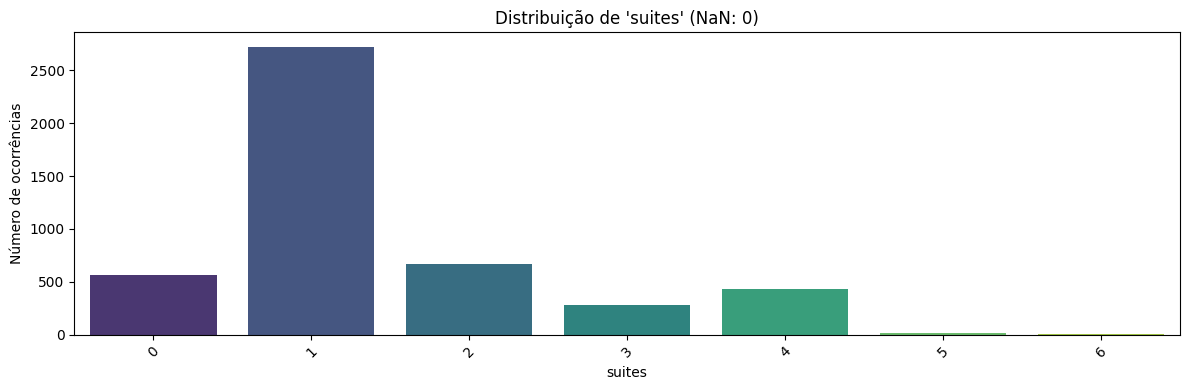


Distribuição de 'vagas' (valores ausentes: 0)


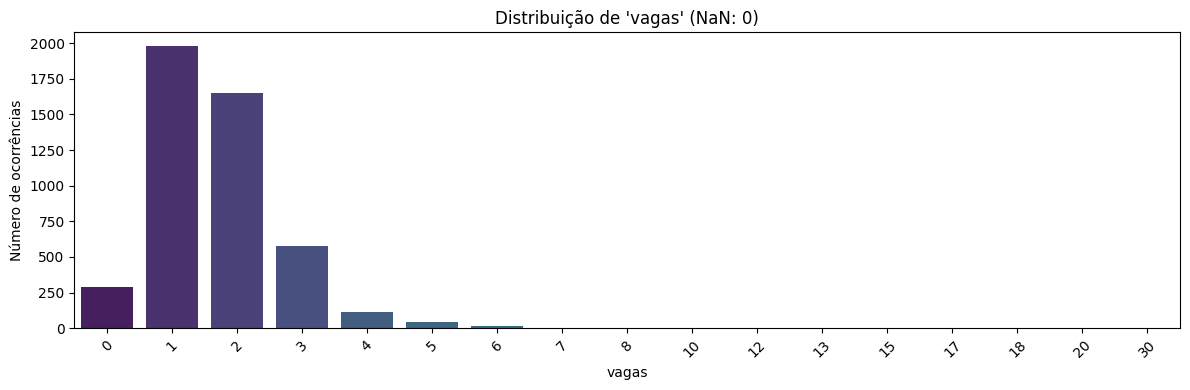


Distribuição de 'churrasqueira' (valores ausentes: 0)


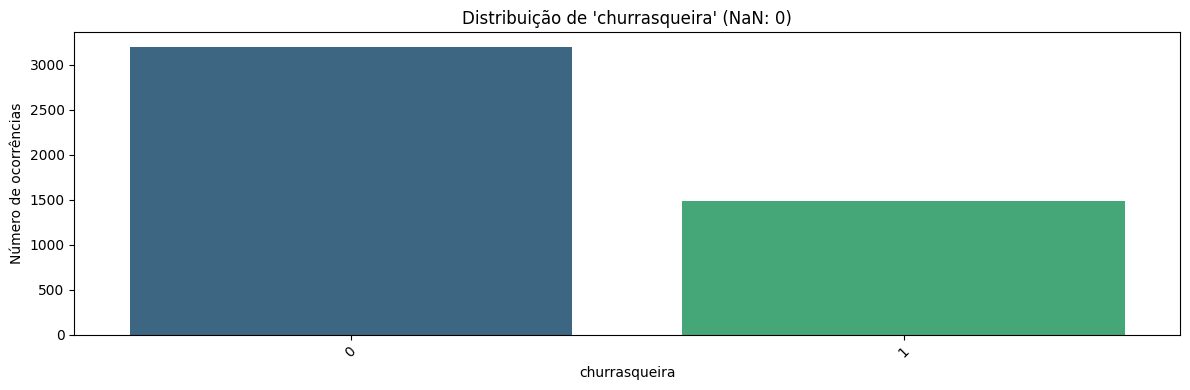


Distribuição de 'estacionamento' (valores ausentes: 0)


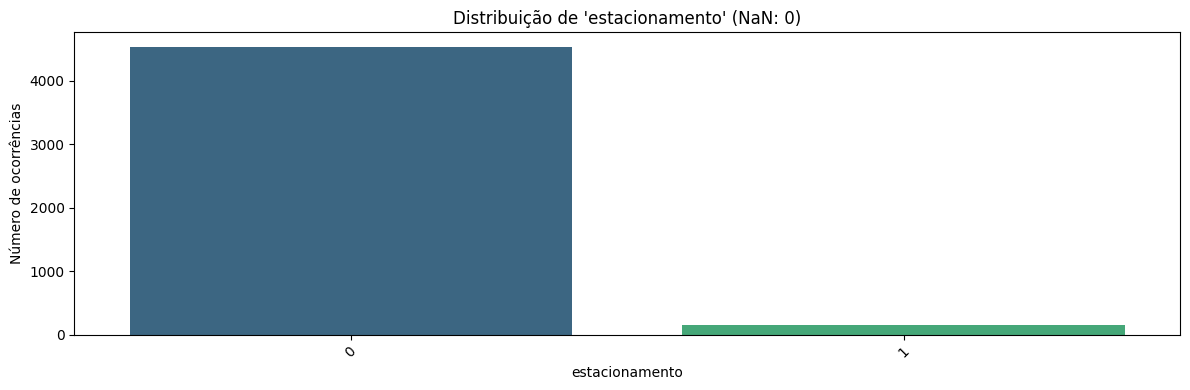


Distribuição de 'piscina' (valores ausentes: 0)


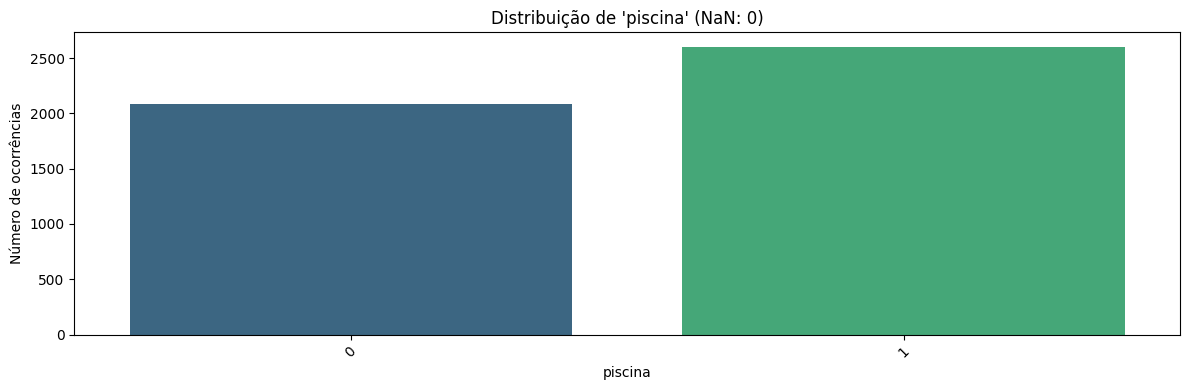


Distribuição de 'playground' (valores ausentes: 0)


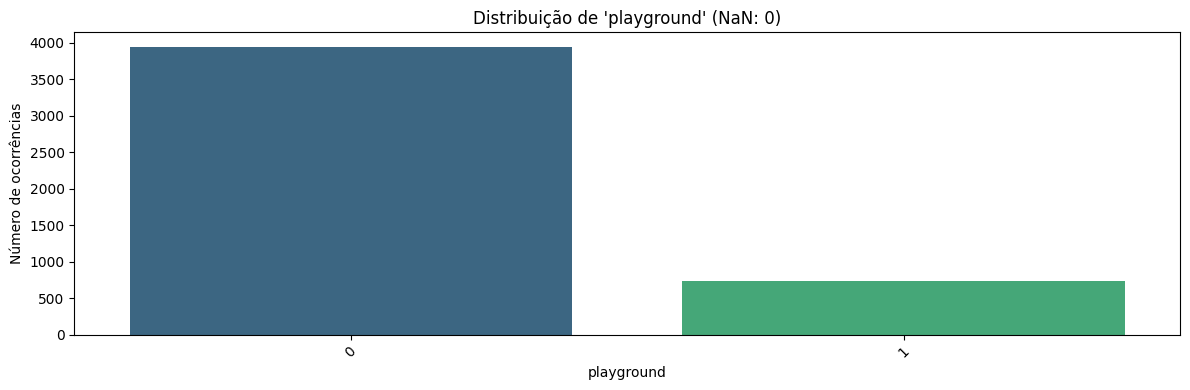


Distribuição de 'quadra' (valores ausentes: 0)


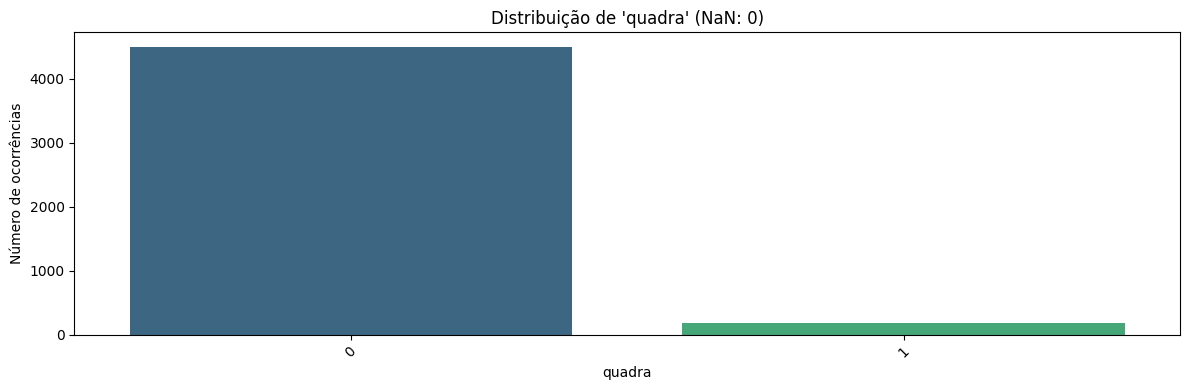


Distribuição de 's_festas' (valores ausentes: 0)


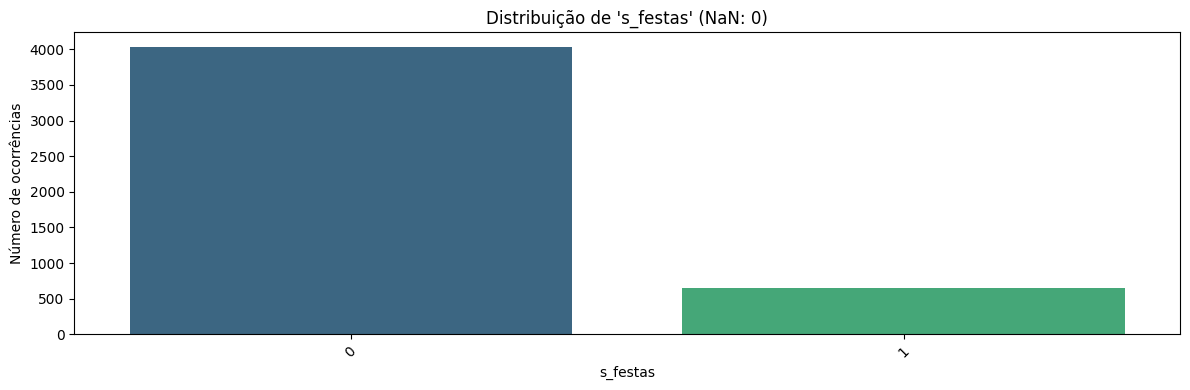


Distribuição de 's_jogos' (valores ausentes: 0)


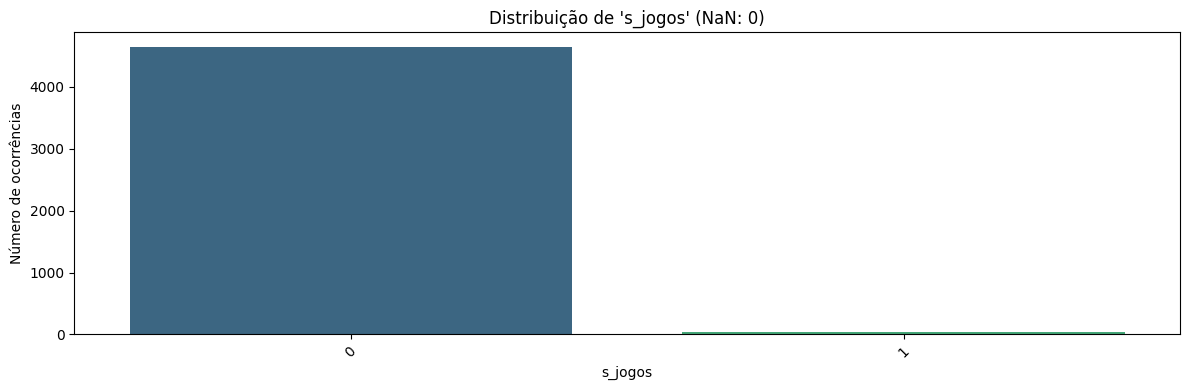


Distribuição de 's_ginastica' (valores ausentes: 0)


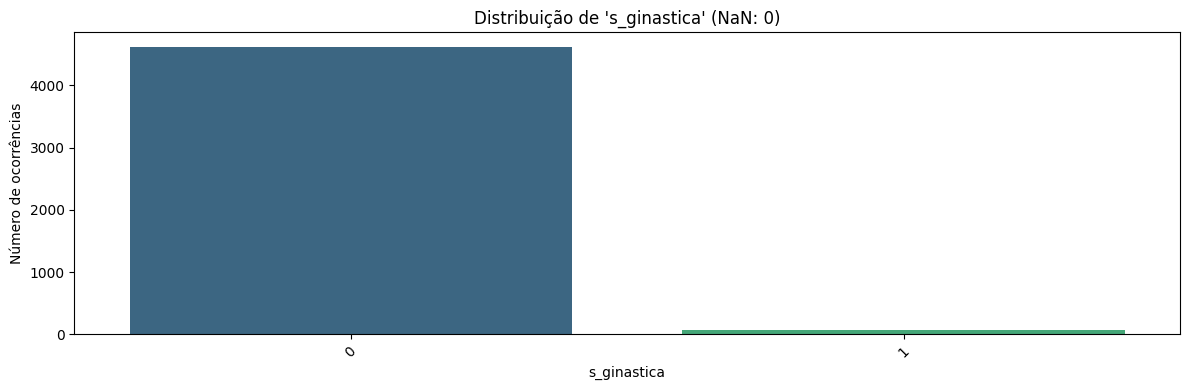


Distribuição de 'sauna' (valores ausentes: 0)


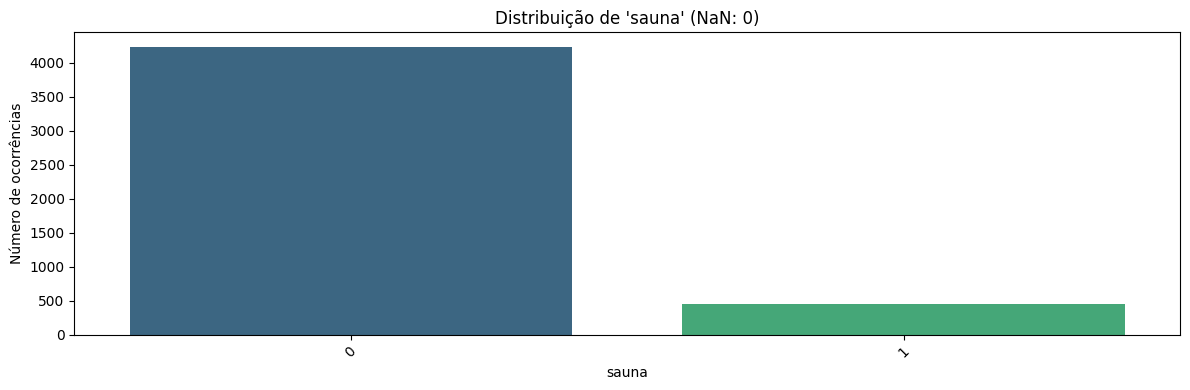


Distribuição de 'vista_mar' (valores ausentes: 0)


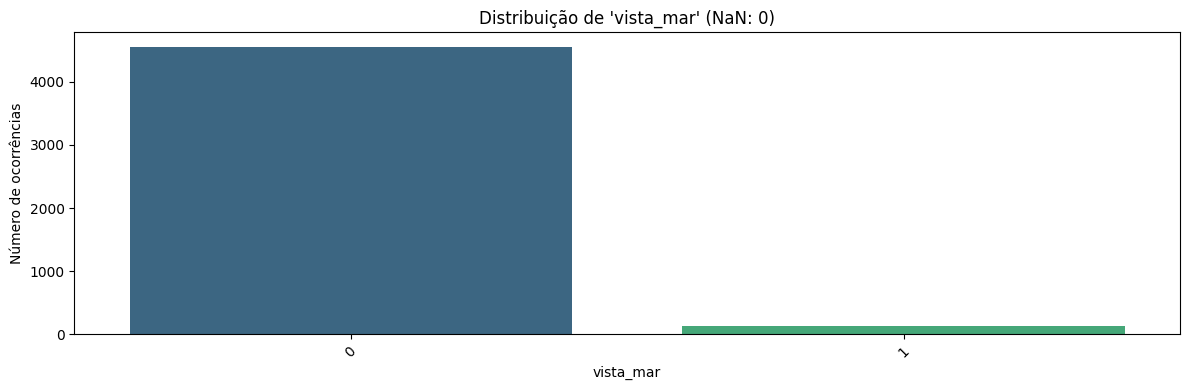

In [22]:
# Lista de features categóricas para exibição em barplot
features_categoricas = [
    'tipo', 
    'bairro', 
    'tipo_vendedor',
    'quartos', 
    'suites', 
    'vagas', 
#   'diferenciais',
    'churrasqueira', 
    'estacionamento',
    'piscina', 
    'playground', 
    'quadra',
    's_festas', 
    's_jogos', 
    's_ginastica',
    'sauna', 
    'vista_mar', 
]

# Loop por cada coluna da lista
for col in features_categoricas:
    missing = train_df[col].isna().sum()
    print(f"\nDistribuição de '{col}' (valores ausentes: {missing})")

    # Contagem das ocorrências (ignorando os NaN)
    counts = train_df[col].value_counts(dropna=True).sort_index()

    # Criação de um DataFrame para exibição
    data = pd.DataFrame({
        'value': counts.index.astype(str),
        'occurrences': counts.values
    })

    # Exibição do gráfico
    plt.figure(figsize=(12, 4))
    sns.barplot(data=data, x='value', y='occurrences', hue='value', palette='viridis', legend=False)
    plt.title(f"Distribuição de '{col}' (NaN: {missing})")
    plt.xlabel(col)
    plt.ylabel("Número de ocorrências")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Plotagem dos distribuições das features numéricas

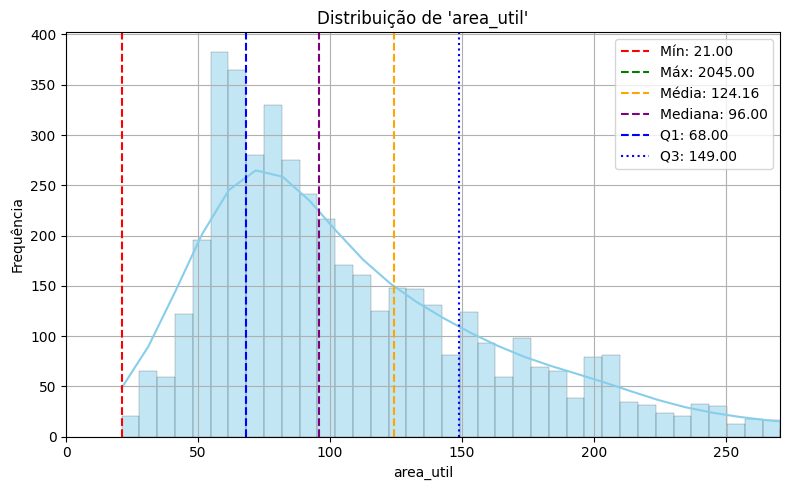

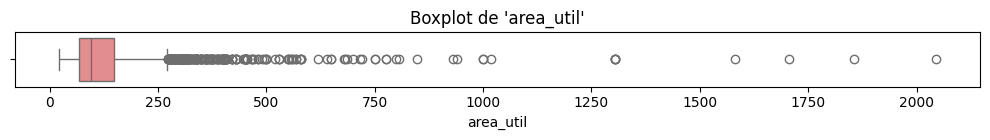

In [23]:
# Estatísticas básicas
data = train_df['area_util']
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
nan_count = data.isna().sum()

# Exibição do gráfico
plt.figure(figsize=(8, 5))
sns.histplot(data=data, kde=True, bins=300, color='skyblue')
plt.title("Distribuição de 'area_util'")
plt.xlabel('area_util')
plt.ylabel("Frequência")
plt.xlim(0, upper_bound)

 # Linhas de estatísticas
plt.axvline(min_val, color='red', linestyle='--', label=f'Mín: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Máx: {max_val:.2f}')
plt.axvline(mean_val, color='orange', linestyle='--', label=f'Média: {mean_val:.2f}')
plt.axvline(median_val, color='purple', linestyle='--', label=f'Mediana: {median_val:.2f}')
plt.axvline(q1, color='blue', linestyle='--', label=f'Q1: {q1:.2f}')
plt.axvline(q3, color='blue', linestyle=':', label=f'Q3: {q3:.2f}')

 # Legenda
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot horizontal
plt.figure(figsize=(10, 1.5))
sns.boxplot(data=data, orient='h', color='lightcoral')
plt.title("Boxplot de 'area_util'")
plt.xlabel("area_util")
plt.tight_layout()
plt.show()

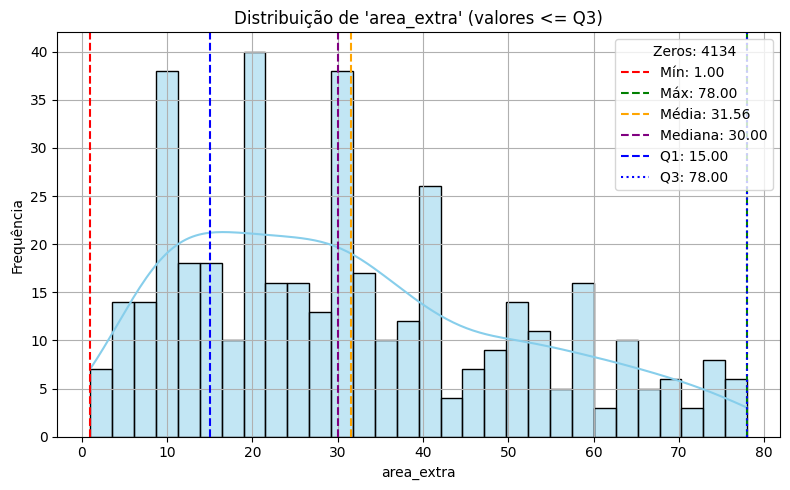

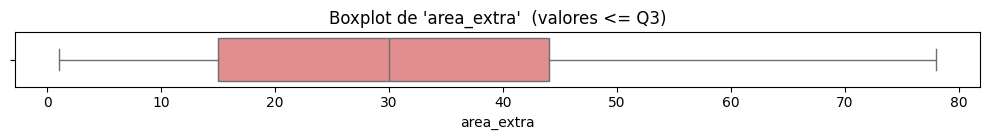

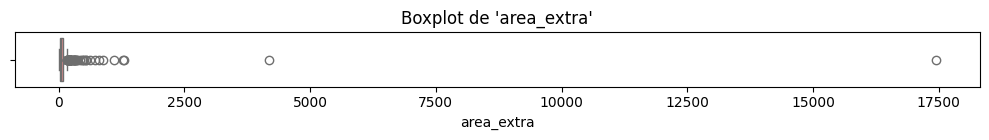

In [24]:
# Dados originais com zeros incluídos
data = train_df['area_extra']
zeros_count = (data == 0).sum()
data = data[data != 0]

# Filtrar valores maiores que Q3 para o gráfico (mantendo zeros)
q3 = data.quantile(0.75)
data_filtrada = data[data <= q3]

min_val = data_filtrada.min()
max_val = data_filtrada.max()
mean_val = data_filtrada.mean()
median_val = data_filtrada.median()
q1 = data_filtrada.quantile(0.25)

# Exibição do gráfico
plt.figure(figsize=(8, 5))
sns.histplot(data=data_filtrada, kde=True, bins=30, color='skyblue')
plt.title("Distribuição de 'area_extra' (valores <= Q3)")
plt.xlabel('area_extra')
plt.ylabel("Frequência")

# Linhas de estatísticas
plt.axvline(min_val, color='red', linestyle='--', label=f'Mín: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Máx: {max_val:.2f}')
plt.axvline(mean_val, color='orange', linestyle='--', label=f'Média: {mean_val:.2f}')
plt.axvline(median_val, color='purple', linestyle='--', label=f'Mediana: {median_val:.2f}')
plt.axvline(q1, color='blue', linestyle='--', label=f'Q1: {q1:.2f}')
plt.axvline(q3, color='blue', linestyle=':', label=f'Q3: {q3:.2f}')

# Legenda incluindo a contagem de zeros
plt.legend(title=f'Zeros: {zeros_count}', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot horizontal
plt.figure(figsize=(10, 1.5))
sns.boxplot(data=data_filtrada, orient='h', color='lightcoral')
plt.title("Boxplot de 'area_extra'  (valores <= Q3)")
plt.xlabel("area_extra")
plt.tight_layout()
plt.show()

# Boxplot horizontal
plt.figure(figsize=(10, 1.5))
sns.boxplot(data=data, orient='h', color='lightcoral')
plt.title("Boxplot de 'area_extra'")
plt.xlabel("area_extra")
plt.tight_layout()
plt.show()

Observam-se valores muito extremos.

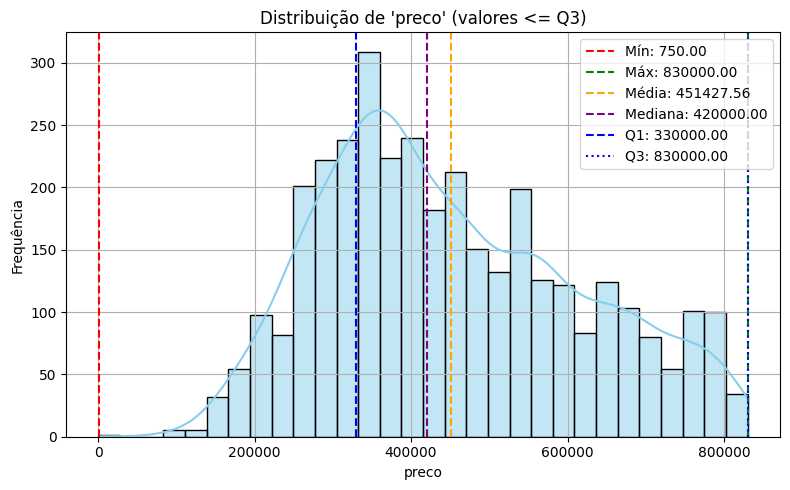

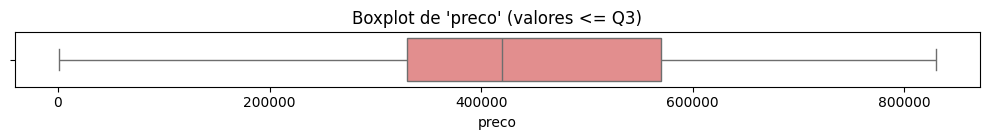

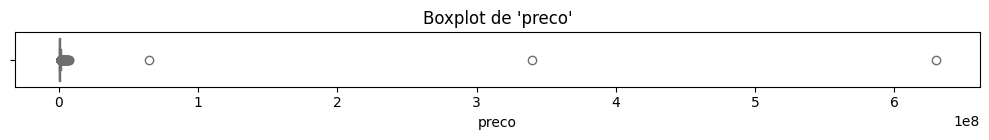

In [25]:
# Dados originais com zeros incluídos
data = train_df['preco']

# Filtrar valores maiores que Q3 para o gráfico (mantendo zeros)
q3 = data.quantile(0.75)
data_filtrada = data[data <= q3]

min_val = data_filtrada.min()
max_val = data_filtrada.max()
mean_val = data_filtrada.mean()
median_val = data_filtrada.median()
q1 = data_filtrada.quantile(0.25)

# Exibição do gráfico
plt.figure(figsize=(8, 5))
sns.histplot(data=data_filtrada, kde=True, bins=30, color='skyblue')
plt.title("Distribuição de 'preco' (valores <= Q3)")
plt.xlabel('preco')
plt.ylabel("Frequência")

# Linhas de estatísticas
plt.axvline(min_val, color='red', linestyle='--', label=f'Mín: {min_val:.2f}')
plt.axvline(max_val, color='green', linestyle='--', label=f'Máx: {max_val:.2f}')
plt.axvline(mean_val, color='orange', linestyle='--', label=f'Média: {mean_val:.2f}')
plt.axvline(median_val, color='purple', linestyle='--', label=f'Mediana: {median_val:.2f}')
plt.axvline(q1, color='blue', linestyle='--', label=f'Q1: {q1:.2f}')
plt.axvline(q3, color='blue', linestyle=':', label=f'Q3: {q3:.2f}')

# Legenda incluindo a contagem de zeros
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot horizontal
plt.figure(figsize=(10, 1.5))
sns.boxplot(data=data_filtrada, orient='h', color='lightcoral')
plt.title("Boxplot de 'preco' (valores <= Q3)")
plt.xlabel("preco")
plt.tight_layout()
plt.show()

# Boxplot horizontal
plt.figure(figsize=(10, 1.5))
sns.boxplot(data=data, orient='h', color='lightcoral')
plt.title("Boxplot de 'preco'")
plt.xlabel("preco")
plt.tight_layout()
plt.show()

Novamente, observam-se preços extremos, tanto muito altos quanto muito baixos. Será necessário filtrá-los, pois se trata da variável alvo.

## Tratamento das palavras na coluna diferenciais

### Análise das palavras presentes na coluna

In [27]:
# Coleta das palavras
todos_os_termos = []

# Lista básica de palavras de ligação (stopwords)
stopwords = {
    'e', 'nenhum', 'de', 'frente', 'para', 'o', 'com'
}

for texto in train_df['diferenciais'].dropna():
    palavras = texto.lower().split()
    palavras_filtradas = [p for p in palavras if p not in stopwords]
    todos_os_termos.extend(palavras_filtradas)

# Contagem das frequências
contagem = Counter(todos_os_termos)

# Exibição das 35 palavras mais frequentes
print("Distribuição dos diferenciais:")
for termo, freq in contagem.most_common(35):
    print(f"{termo}: {freq}")


Distribuição dos diferenciais:
piscina: 2602
churrasqueira: 1484
playground: 737
salao: 679
festas: 647
sauna: 451
copa: 321
estacionamento: 144
visitantes: 144
mar: 128
campo: 108
futebol: 108
esquina: 101
quadra: 76
poliesportiva: 75
sala: 64
ginastica: 64
jogos: 32
children: 6
care: 6
vestiario: 4
hidromassagem: 3
squash: 1


Vamos contar o número de 1 nas colunas binárias que já temos nas features, para comparar a quantidade de ocorrências.

In [ ]:
colunas = [
    'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra',
    's_festas', 's_jogos', 's_ginastica', 'sauna', 'vista_mar'
]

# Contagem dos 1 (presença do equipamento)
contagem = train_df[colunas].sum()

# Exibição
for col, val in contagem.items():
    print(f"{col}: {val}")


churrasqueira: 1484
estacionamento: 144
piscina: 2602
playground: 737
quadra: 183
s_festas: 647
s_jogos: 32
s_ginastica: 64
sauna: 451
vista_mar: 128


Ao comparar essas duas listas, observamos que as colunas binárias já existentes — como churrasqueira, estacionamento, piscina, entre outras — possuem exatamente a mesma quantidade de valores 1 que o número de vezes em que essas palavras aparecem na coluna 'diferenciais'. Isso mostra que essas informações já estavam representadas de forma estruturada nos dados.

Segue a lista de palavras obtidas na coluna 'diferenciais'. No início, estão aquelas cujas features já existem e cuja informação já possuímos. No final, estão as features que ainda não existem e que precisamos criar para aumentar a quantidade de informações disponíveis:

- churrasqueira *
- estacionamento *
- piscina *
- playground *
- quadra * (= campo de futebol + quadra poliesportiva)
- s_festas *
- s_jogos *
- s_ginastica *
- sauna *
- vista_mar *

Novas features a criar:

- futebol
- poliesportiva
- esquina
- copa
- children
- vestiário
- hidromassagem
- squash

### Extração das palavras e criação de novas features a partir de 'diferenciais'

In [36]:
def extrair_diferenciais(df, coluna='diferenciais'):
    # Lista de palavras-chave a extrair
    palavras_chave = [
        'futbol',
        'poliesportiva',
        'esquina',
        'copa',
        'children',
        'vestiario',
        'hidromassagem',
        'squash'
    ]
    
    # Garantir que a coluna seja do tipo string
    df[coluna] = df[coluna].astype(str).str.lower()
    
    # Criar uma coluna para cada palavra-chave
    for palavra in palavras_chave:
        df[palavra] = df[coluna].apply(lambda x: 1 if palavra in x.split() else 0)
    
    return df

extrair_diferenciais(train_df)
extrair_diferenciais(test_df)

,Id,tipo,bairro,tipo_vendedor,quartos,suites,vagas,area_util,area_extra,diferenciais,churrasqueira,estacionamento,piscina,playground,quadra,s_festas,s_jogos,s_ginastica,sauna,vista_mar,futbol,poliesportiva,esquina,copa,children,vestiario,hidromassagem,squash
0,0,Apartamento,Pina,Imobiliaria,4,4,3,182,0,copa e playground,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,1,Apartamento,Tamarineira,Imobiliaria,2,0,1,85,0,nenhum,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,Apartamento,Boa Viagem,Imobiliaria,3,1,2,115,20,piscina e churrasqueira,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,Apartamento,Iputinga,Imobiliaria,3,0,1,92,0,nenhum,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,Apartamento,Engenho do Meio,Imobiliaria,3,1,1,65,0,piscina e copa,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,Apartamento,Poco da Panela,Imobiliaria,2,1,2,100,0,nenhum,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1996,1996,Apartamento,Madalena,Imobiliaria,3,1,1,90,0,nenhum,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1997,1997,Apartamento,Boa Viagem,Imobiliaria,3,1,1,73,0,piscina e salao de festas,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1998,1998,Apartamento,Torre,Imobiliaria,4,3,2,112,2810,piscina e frente para o mar,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


## Engenharia de Features

Criação de novas features relevantes a partir das informações já disponíveis.

In [37]:
def engenharia_de_features(df):
    df = df.copy()

    # Área total
    df['area_total'] = df['area_util'] + df['area_extra']

    # Área útil por quarto
    df['area_por_quarto'] = df['area_util'] / df['quartos'].replace(0, np.nan)

    # Área útil por cômodo (quartos + suítes)
    df['area_por_comodo'] = df['area_util'] / (df['quartos'] + df['suites']).replace(0, np.nan)

    # Razão suítes / quartos
    df['proporcao_suites'] = df['suites'] / df['quartos'].replace(0, np.nan)

    # Equipamentos de luxo
    equipamentos = [
        'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra', 's_festas',
        's_jogos', 's_ginastica', 'sauna', 'vista_mar', 'futbol', 'poliesportiva',
        'esquina', 'copa', 'children', 'vestiario', 'hidromassagem', 'squash'
    ]
    df['n_equipamentos'] = df[equipamentos].sum(axis=1)

    return df

train_df = engenharia_de_features(train_df)
test_df = engenharia_de_features(test_df)

## Tratamento de valores extremos

In [38]:
colunas = ['area_util', 'preco']

IQR = 1.55  # Valor que obtém os melhores resultados após várias tentativas

for col in colunas:
    dados = train_df[col].dropna()
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - IQR * iqr
    limite_superior = q3 + IQR * iqr
    valor_min = dados.min()
    valor_max = dados.max()

    print(f"\n--- {col} ---")
    print(f"Mínimo : {valor_min:.2f}")
    print(f"Máximo : {valor_max:.2f}")
    print(f"Q1 : {q1:.2f}")
    print(f"Q3 : {q3:.2f}")
    print(f"IQR : {iqr:.2f}")
    print(f"Limite inferior (Q1 - {IQR}*IQR) : {limite_inferior:.2f}")
    print(f"Limite superior (Q3 + {IQR}*IQR) : {limite_superior:.2f}")

# Tratamento especial para 'area_extra' (excluindo os zeros)
dados = train_df['area_extra']
dados_filtrados = dados[(dados != 0) & (~dados.isna())]

q1 = dados_filtrados.quantile(0.25)
q3 = dados_filtrados.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - IQR * iqr
limite_superior = q3 + IQR * iqr
valor_min = dados_filtrados.min()
valor_max = dados_filtrados.max()

print(f"\n--- area_extra (sem zeros) ---")
print(f"Mínimo : {valor_min:.2f}")
print(f"Máximo : {valor_max:.2f}")
print(f"Q1 : {q1:.2f}")
print(f"Q3 : {q3:.2f}")
print(f"IQR : {iqr:.2f}")
print(f"Limite inferior (Q1 - {IQR}*IQR) : {limite_inferior:.2f}")
print(f"Limite superior (Q3 + {IQR}*IQR) : {limite_superior:.2f}")



--- area_util ---
Mínimo : 21.00
Máximo : 2045.00
Q1 : 68.00
Q3 : 149.00
IQR : 81.00
Limite inferior (Q1 - 1.55*IQR) : -57.55
Limite superior (Q3 + 1.55*IQR) : 274.55

--- preco ---
Mínimo : 750.00
Máximo : 630000000.00
Q1 : 355000.00
Q3 : 830000.00
IQR : 475000.00
Limite inferior (Q1 - 1.55*IQR) : -381250.00
Limite superior (Q3 + 1.55*IQR) : 1566250.00

--- area_extra (sem zeros) ---
Mínimo : 1.00
Máximo : 17450.00
Q1 : 20.00
Q3 : 78.00
IQR : 58.00
Limite inferior (Q1 - 1.55*IQR) : -69.90
Limite superior (Q3 + 1.55*IQR) : 167.90


In [39]:
# --- Remoção dos outliers para preco, area_util, area_extra usando o método IQR ---

# --- Definir os limites mínimo e máximo ---
limites = {
    'area_util': (0, 2045.00),
    'preco': (1000, 1566250.00),  # Única coluna em que filtramos os outliers
    'area_extra': (0, 17450.00)
}

# --- Aplicar o filtro segundo os limites definidos ---
mascaras = []

for coluna, (val_min, val_max) in limites.items():
    mascara = (train_df[coluna] >= val_min) & (train_df[coluna] <= val_max)
    mascaras.append(mascara)

# Combinar as máscaras
mascara_total = mascaras[0]
for m in mascaras[1:]:
    mascara_total &= m

# Filtrar o DataFrame
train_df_filtrado = train_df[mascara_total]

# --- Exibição dos resultados ---
print("Filtro baseado em limites manuais:")
for col, (vmin, vmax) in limites.items():
    print(f"- {col}: entre {vmin} e {vmax}")

print(f"\nLinhas antes do filtro: {len(train_df)}")
print(f"Linhas após o filtro: {len(train_df_filtrado)}")
print(f"Número de linhas removidas: {len(train_df) - len(train_df_filtrado)}")

Filtro baseado em limites manuais:
- area_util: entre 0 e 2045.0
- preco: entre 1000 e 1566250.0
- area_extra: entre 0 e 17450.0

Linhas antes do filtro: 4683
Linhas após o filtro: 4369
Número de linhas removidas: 314


## Cálculo da importância das variáveis com LGBMClassifier

Este código prepara os dados para o treinamento de um modelo LightGBM. Ele codifica as colunas categóricas com LabelEncoder para converter as categorias em números. Em seguida, separa os dados em variáveis explicativas (X) e variável alvo (y).  
  
O modelo LGBMClassifier é então treinado com esses dados. Após o treinamento, a importância de cada variável é extraída via feature_importances_. Assim, conhecemos as features mais importantes para o treinamento do modelo, bem como aquelas que podem ser removidas.

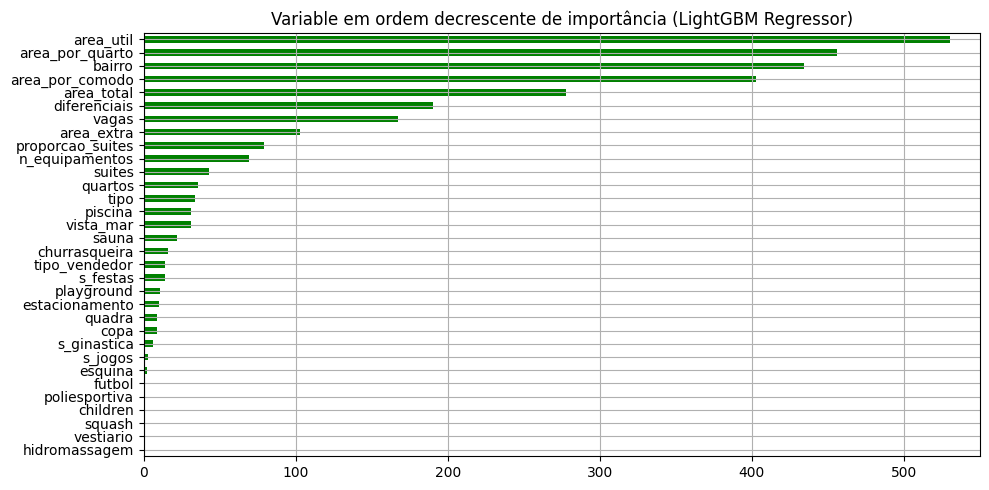

In [40]:
# Preparação
df_model = train_df_filtrado.copy()

# Codificação simples das colunas categóricas
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Separação X / y
X = df_model.drop(columns=['Id', 'preco'])
y = df_model['preco']

# Modelo inicial
model = LGBMRegressor(
    force_row_wise=True,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)
model.fit(X, y)

# Importância
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

# Seleção das variáveis
top = importances_sorted.head(40)

# Exibição das 10 variáveis mais importantes
plt.figure(figsize=(10, 5))
top.plot(kind='barh', color='green')
plt.title("Variable em ordem decrescente de importância (LightGBM Regressor)")
plt.gca().invert_yaxis()
plt.xlim(0, top.max() + 20)
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
# --- Seleção segundo um limite ---
limite_importancia = 0
features_a_manter = importances_sorted[importances_sorted >= limite_importancia].index.tolist()

# Colunas a manter + o alvo + eventualmente id_solicitante
colunas_a_manter_treino = features_a_manter + ['Id', 'preco']
colunas_a_manter_teste = features_a_manter + ['Id']

# Remover as colunas não desejadas
train_df_reduzido = train_df_filtrado[colunas_a_manter_treino].copy()
test_df_reduzido = test_df[colunas_a_manter_teste].copy()

num_variaveis_removidas = len(importances_sorted) - len(features_a_manter)
print(f"Número de variáveis mantidas: {len(features_a_manter)}")
print(f"Número de variáveis removidas: {num_variaveis_removidas}")


Número de variáveis mantidas: 32
Número de variáveis removidas: 0


Após várias tentativas, observamos que o modelo de regressão lida bem com a redundância dos dados, a multicolinearidade. Remover colunas inúteis não altera o resultado final, então optei por não remover nenhuma."

## Pré-processamento dos dados

In [44]:
# --- Pré-processamento ---
def preprocess(df):
    df = df.copy()

    # Identificar automaticamente as colunas categóricas (do tipo 'object' ou 'category')
    colunas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Codificação OneHot
    df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)
    return df

- Começamos separando as variáveis explicativas X e o alvo y.

- Não realizo imputação, pois não há valores ausentes, e não aplico escalonamento, pois é desnecessário com o LGBM; o pré-processamento se limita a aplicar um one-hot encoder.

- Para o conjunto de teste, aplicamos o mesmo one-hot encoder para manter a consistência das transformações.

- Em seguida, harmonizamos as colunas entre treino e teste: adicionamos as colunas que faltam no teste preenchendo com zeros e removemos as colunas extras.

- Depois, garantimos que a ordem das colunas seja idêntica nos dois DataFrames.

In [45]:
# Separar features e alvo
X = train_df_reduzido.drop(columns=['Id', 'preco'])
y = train_df_reduzido['preco']

# Pré-processamento do conjunto de treino
X_processado = preprocess(X)

# Pré-processamento do conjunto de teste
test_processado = preprocess(test_df_reduzido.drop(columns=['Id']))

# --- Harmonização treino/teste ---
# Adicionar colunas que faltam no test_processado com valor 0
colunas_faltando = set(X_processado.columns) - set(test_processado.columns)
for col in colunas_faltando:
    test_processado[col] = 0

# Remover colunas extras que existem no test_processado mas não no X_processado
colunas_extras = set(test_processado.columns) - set(X_processado.columns)
test_processado.drop(columns=colunas_extras, inplace=True)

# Reordenar as colunas do test_processado para corresponder à ordem de X_processado
test_processado = test_processado[X_processado.columns]

Esta linha divide os dados pré-processados (X_processed e y) em dois conjuntos:

- um conjunto de treinamento (X_train, y_train) que conterá 80% dos dados,

- um conjunto de validação (X_val, y_val) com os 20% restantes.

A validação serve para avaliar o desempenho do modelo em dados não vistos durante o treinamento.

O parâmetro random_state=42 fixa a semente aleatória para que a divisão seja reprodutível.

In [46]:
# --- Separação treino / validação ---
X_train, X_val, y_train, y_val = train_test_split(X_processado, y, test_size=0.2, random_state=42)

## Treinamento dos modelos e cálculo da acurácia e validação cruzada

Começamos definindo a função de avaliação RMSPE :

In [12]:
def rmspe(y_true, y_pred):
    # Evitar divisão por zero (caso tenha algum y_true == 0)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filtrar apenas valores onde y_true != 0
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

Este bloco treina três modelos diferentes:

Random Forest Regressor,  
XGBoost Regressor,  
LightGBM Regressor 

Cada modelo é treinado com os dados de treinamento e depois testado no conjunto de validação.

A precisão (rmspe_score) é calculada para comparar o desempenho deles nessa validação.

In [47]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
print("Random Forest:")
print(" RMSPE:", rmspe(y_val, y_pred_rf))

# --- XGBoost ---
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)
print("XGBoost:")
print(" RMSPE:", rmspe(y_val, y_pred_xgb))

# --- LightGBM ---
lgbm = LGBMRegressor(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_val)
print("LightGBM:")
print(" RMSPE:", rmspe(y_val, y_pred_lgbm))


Random Forest:
 RMSPE: 0.26986202275147686
XGBoost:
 RMSPE: 0.2724405064698925
LightGBM:
 RMSPE: 0.2604223763678119


In [48]:
# Cross-validation com RMSPE
scores_rf = cross_val_score(rf, X_processado, y, cv=5,
    scoring=lambda est, X, y: -rmspe(y, est.predict(X)))
print("RMSPE médio validação cruzada (Random Forest):", -scores_rf.mean())

scores_xgb = cross_val_score(xgb, X_processado, y, cv=5,
    scoring=lambda est, X, y: -rmspe(y, est.predict(X)))
print("RMSPE médio validação cruzada (XGBoost):", -scores_xgb.mean())

scores_lgbm = cross_val_score(lgbm, X_processado, y, cv=5,
    scoring=lambda est, X, y: -rmspe(y, est.predict(X)))
print("RMSPE médio validação cruzada (LightGBM):", -scores_lgbm.mean())

RMSPE médio validação cruzada (Random Forest): 0.24933995997929062
RMSPE médio validação cruzada (XGBoost): 0.24316099592057588
RMSPE médio validação cruzada (LightGBM): 0.23793377058127127


## Busca de hiperparâmetros otimizados

Este código realiza uma otimização de hiperparâmetros para um modelo de regressão LightGBM usando a biblioteca Optuna.

- A função objective define os hiperparâmetros a serem testados (número de folhas, profundidade máxima, taxa de aprendizado, etc.) com intervalos possíveis fornecidos pelo Optuna.

- O modelo é avaliado por validação cruzada com 5 folds usando o erro RMSPE (Root Mean Squared Percentage Error) como métrica de desempenho.

In [50]:
# --- Função objetivo do Optuna ---
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 120),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbosity': -1
    }

    model = LGBMRegressor(**params)
    
    # Utilização de validação cruzada com RMSPE
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_processado, y, cv=kf,
                             scoring=lambda est, X, y: -rmspe(y, est.predict(X)))
    
    return -np.mean(scores)  # Optuna minimiza, então invertemos o RMSPE

# --- Execução do estudo ---
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- Melhores hiperparâmetros ---
print("Melhores hiperparâmetros:", study.best_params)
print("Score RMSPE (validação cruzada):", study.best_value)

[I 2025-07-16 12:07:11,217] A new study created in memory with name: no-name-dce613f6-6ad4-40d9-a2fe-8578c5a1c37f
Best trial: 0. Best value: 0.248048:   2%|▏         | 1/50 [00:04<03:31,  4.33s/it]

[I 2025-07-16 12:07:15,546] Trial 0 finished with value: 0.2480482059865785 and parameters: {'num_leaves': 78, 'max_depth': 22, 'learning_rate': 0.05703099319104491, 'n_estimators': 556, 'min_child_samples': 19, 'subsample': 0.7056485970446471, 'colsample_bytree': 0.8697276596825727, 'reg_alpha': 0.7764539072279529, 'reg_lambda': 0.8548606637325761}. Best is trial 0 with value: 0.2480482059865785.


Best trial: 1. Best value: 0.241989:   4%|▍         | 2/50 [00:05<01:50,  2.30s/it]

[I 2025-07-16 12:07:16,424] Trial 1 finished with value: 0.24198918171292877 and parameters: {'num_leaves': 53, 'max_depth': 6, 'learning_rate': 0.07559320579190691, 'n_estimators': 332, 'min_child_samples': 39, 'subsample': 0.6075324539824624, 'colsample_bytree': 0.7193742298332773, 'reg_alpha': 0.3238672899679852, 'reg_lambda': 0.5251540542278647}. Best is trial 1 with value: 0.24198918171292877.


Best trial: 1. Best value: 0.241989:   6%|▌         | 3/50 [00:10<02:55,  3.74s/it]

...

[I 2025-07-16 12:08:58,273] Trial 47 finished with value: 0.23836757998393404 and parameters: {'num_leaves': 58, 'max_depth': 11, 'learning_rate': 0.04056783870080802, 'n_estimators': 366, 'min_child_samples': 19, 'subsample': 0.9523960406839961, 'colsample_bytree': 0.8048587313108679, 'reg_alpha': 0.7013156920930866, 'reg_lambda': 0.14227091167789585}. Best is trial 16 with value: 0.23722124221132196.


Best trial: 16. Best value: 0.237221:  98%|█████████▊| 49/50 [01:48<00:01,  1.63s/it]

[I 2025-07-16 12:08:59,878] Trial 48 finished with value: 0.3612854071804913 and parameters: {'num_leaves': 39, 'max_depth': 9, 'learning_rate': 0.0055209228646309096, 'n_estimators': 224, 'min_child_samples': 12, 'subsample': 0.9368054599707512, 'colsample_bytree': 0.9762578277473515, 'reg_alpha': 0.2345867605914237, 'reg_lambda': 0.38215967027084385}. Best is trial 16 with value: 0.23722124221132196.


Best trial: 16. Best value: 0.237221: 100%|██████████| 50/50 [01:50<00:00,  2.21s/it]

[I 2025-07-16 12:09:01,697] Trial 49 finished with value: 0.23979938909476264 and parameters: {'num_leaves': 20, 'max_depth': 13, 'learning_rate': 0.032243287731348685, 'n_estimators': 521, 'min_child_samples': 32, 'subsample': 0.7187474841301189, 'colsample_bytree': 0.9205580978972304, 'reg_alpha': 0.11053364317654996, 'reg_lambda': 0.47624408962884457}. Best is trial 16 with value: 0.23722124221132196.
Melhores hiperparâmetros: {'num_leaves': 44, 'max_depth': 8, 'learning_rate': 0.030038479493476992, 'n_estimators': 326, 'min_child_samples': 10, 'subsample': 0.7681494460546978, 'colsample_bytree': 0.8037069094659468, 'reg_alpha': 0.8477904411883148, 'reg_lambda': 0.7373020317750875}
Score RMSPE (validação cruzada): 0.23722124221132196


## Predição no conjunto de teste e preparação do arquivo de submissão


In [51]:
# Treinar o modelo com os melhores parâmetros
final_lgbm = LGBMRegressor(**study.best_params)
final_lgbm.fit(X_processado, y)

LGBMRegressor(colsample_bytree=0.8037069094659468,
              learning_rate=0.030038479493476992, max_depth=8,
              min_child_samples=10, n_estimators=326, num_leaves=44,
              reg_alpha=0.8477904411883148, reg_lambda=0.7373020317750875,
              subsample=0.7681494460546978)

In [52]:
# --- Predição no conjunto de teste e preparação da submissão ---
y_test_pred = final_lgbm.predict(test_processado)
y_test_pred = final_lgbm.predict(test_processado)

# Criação do DataFrame de submissão
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'preco': y_test_pred
})

# Salvar em CSV
submission.to_csv('submission.csv', index=False)
print("Arquivo de submissão salvo: submission.csv")

Arquivo de submissão salvo: submission.csv


## Conclusão

A pontuação final de acurácia que obtive via envio no Kaggle foi: **0,2527**  

# Código-fonte completo em uma única célula


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor
import optuna

train_df = pd.read_csv('data/conjunto_de_treinamento.csv')
test_df = pd.read_csv('data/conjunto_de_teste.csv')

def extrair_diferenciais(df, coluna='diferenciais'):
    palavras_chave = [
        'futbol', 'poliesportiva', 'esquina', 'copa',
        'children', 'vestiario', 'hidromassagem', 'squash'
    ]
    df[coluna] = df[coluna].astype(str).str.lower()
    for palavra in palavras_chave:
        df[palavra] = df[coluna].apply(lambda x: 1 if palavra in x.split() else 0)
    return df

extrair_diferenciais(train_df)
extrair_diferenciais(test_df)

def engenharia_de_features(df):
    df = df.copy()
    df['area_total'] = df['area_util'] + df['area_extra']
    df['area_por_quarto'] = df['area_util'] / df['quartos'].replace(0, np.nan)
    df['area_por_comodo'] = df['area_util'] / (df['quartos'] + df['suites']).replace(0, np.nan)
    df['proporcao_suites'] = df['suites'] / df['quartos'].replace(0, np.nan)
    equipamentos = [
        'churrasqueira', 'estacionamento', 'piscina', 'playground', 'quadra',
        's_festas', 's_jogos', 's_ginastica', 'sauna', 'vista_mar', 'futbol',
        'poliesportiva', 'esquina', 'copa', 'children', 'vestiario',
        'hidromassagem', 'squash'
    ]
    df['n_equipamentos'] = df[equipamentos].sum(axis=1)
    return df

train_df = engenharia_de_features(train_df)
test_df = engenharia_de_features(test_df)

limites = {
    'area_util': (0, 2045.00),
    'preco': (1000, 1566250.00),
    'area_extra': (0, 17450.00)
}

mascara_total = np.ones(len(train_df), dtype=bool)
for coluna, (val_min, val_max) in limites.items():
    mascara_total &= (train_df[coluna] >= val_min) & (train_df[coluna] <= val_max)
train_df_filtrado = train_df[mascara_total]

df_model = train_df_filtrado.copy()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['Id', 'preco'])
y = df_model['preco']

modelo_inicial = LGBMRegressor(force_row_wise=True, random_state=42, n_estimators=100, learning_rate=0.1)
modelo_inicial.fit(X, y)
importances = pd.Series(modelo_inicial.feature_importances_, index=X.columns)
features_a_manter = importances[importances > 0].index.tolist()

colunas_treino = features_a_manter + ['Id', 'preco']
colunas_teste = features_a_manter + ['Id']
train_df_reduzido = train_df_filtrado[colunas_treino].copy()
test_df_reduzido = test_df[colunas_teste].copy()

def preprocess(df):
    colunas_categoricas = df.select_dtypes(include=['object', 'category']).columns
    return pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

X_processado = preprocess(train_df_reduzido.drop(columns=['Id', 'preco']))
test_processado = preprocess(test_df_reduzido.drop(columns=['Id']))

colunas_faltando = set(X_processado.columns) - set(test_processado.columns)
for col in colunas_faltando:
    test_processado[col] = 0
colunas_extras = set(test_processado.columns) - set(X_processado.columns)
test_processado.drop(columns=colunas_extras, inplace=True)
test_processado = test_processado[X_processado.columns]

def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 120),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbosity': -1
    }
    model = LGBMRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_processado, y, cv=kf,
                             scoring=lambda est, X, y: -rmspe(y, est.predict(X)))
    return -np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

final_lgbm = LGBMRegressor(**study.best_params)
final_lgbm.fit(X_processado, y)
y_test_pred = final_lgbm.predict(test_processado)

submission = pd.DataFrame({'Id': test_df['Id'], 'preco': y_test_pred})
submission.to_csv('submission.csv', index=False)


[I 2025-07-16 12:24:21,521] A new study created in memory with name: no-name-5e81230c-efd0-42d6-8675-006ffdf02908
Best trial: 0. Best value: 0.238033:   2%|▏         | 1/50 [00:03<02:40,  3.27s/it]

[I 2025-07-16 12:24:24,789] Trial 0 finished with value: 0.2380327495975266 and parameters: {'num_leaves': 100, 'max_depth': 7, 'learning_rate': 0.0119816522558579, 'n_estimators': 683, 'min_child_samples': 13, 'subsample': 0.7130885039552115, 'colsample_bytree': 0.6363025105378363, 'reg_alpha': 0.7803313520053694, 'reg_lambda': 0.7336525119082447}. Best is trial 0 with value: 0.2380327495975266.


Best trial: 0. Best value: 0.238033:   4%|▍         | 2/50 [00:08<03:36,  4.51s/it]

[I 2025-07-16 12:24:30,169] Trial 1 finished with value: 0.24495820233666027 and parameters: {'num_leaves': 45, 'max_depth': 23, 'learning_rate': 0.03547439324829934, 'n_estimators': 997, 'min_child_samples': 33, 'subsample': 0.7615021784336616, 'colsample_bytree': 0.887734752166984, 'reg_alpha': 0.7455674963502041, 'reg_lambda': 0.3016943958021233}. Best is trial 0 with value: 0.2380327495975266.


Best trial: 0. Best value: 0.238033:   6%|▌         | 3/50 [00:10<02:27,  3.14s/it]

...

[I 2025-07-16 12:27:32,679] Trial 47 finished with value: 0.2404986542232001 and parameters: {'num_leaves': 49, 'max_depth': 13, 'learning_rate': 0.017694048794725685, 'n_estimators': 522, 'min_child_samples': 36, 'subsample': 0.7556741587740124, 'colsample_bytree': 0.6934220304884959, 'reg_alpha': 0.5975225391402796, 'reg_lambda': 0.002612551642312444}. Best is trial 11 with value: 0.23554555043871428.


Best trial: 11. Best value: 0.235546:  98%|█████████▊| 49/50 [03:15<00:03,  3.38s/it]

[I 2025-07-16 12:27:37,305] Trial 48 finished with value: 0.255082370562753 and parameters: {'num_leaves': 109, 'max_depth': 16, 'learning_rate': 0.006349446901320203, 'n_estimators': 468, 'min_child_samples': 20, 'subsample': 0.6226758750370109, 'colsample_bytree': 0.6718657316293668, 'reg_alpha': 0.03780379999444695, 'reg_lambda': 0.8793783641076566}. Best is trial 11 with value: 0.23554555043871428.


Best trial: 11. Best value: 0.235546: 100%|██████████| 50/50 [03:19<00:00,  4.00s/it]


[I 2025-07-16 12:27:41,318] Trial 49 finished with value: 0.23908313015010818 and parameters: {'num_leaves': 103, 'max_depth': 10, 'learning_rate': 0.010582560562446006, 'n_estimators': 642, 'min_child_samples': 16, 'subsample': 0.9070718224592316, 'colsample_bytree': 0.6463467433715429, 'reg_alpha': 0.6813893602414978, 'reg_lambda': 0.950919862022292}. Best is trial 11 with value: 0.23554555043871428.
